Import things -- change the second line below to the number of CPUs/GPUs/TPUs you are using

In [ ]:
import numpyro
numpyro.set_host_device_count(12)

from pathlib import Path
from embers_passes import PassFile, SphericalSpline, eval_spline_batch, make_knots_from_grid

import numpy as np

import matplotlib.pyplot as plt

from pyuvdata import UVBeam

from scipy.stats import binned_statistic_2d



from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from jax import random
import jax.numpy as jnp
import jax

import pickle

Load up MWA Beam simulation at ORBCOMM frequency -- need to point this to local path!

In [ ]:
mwa_beamfile = ""
delays = np.zeros(16, dtype=int)
delays = np.array([delays, delays])

beam = UVBeam.from_file(
    mwa_beamfile,
    freq_range=[136e6, 138e6],
    delays=delays,
    za_range=(0,90)
    )
beam.peak_normalize()
beam.efield_to_power()

Only one available frequency in freq_range.


Load up example passes for a tile with known issue

In [31]:
beam.polarization_array

array([-5, -6, -7, -8])

In [60]:
pol = "XX"
pol_ind_dict = {
    "XX": np.where(beam.polarization_array == -5)[0][0],
    "YY": np.where(beam.polarization_array == -6)[0][0]
}
pol_ind = pol_ind_dict[pol]

path = Path(f"../passes/rf0/S08{pol}_rf0{pol}_passes.h5")
pf = PassFile(path)
print(pf)
passes = pf.read_passes(pointing=0)
print(f"Number of passes: {len(passes)}")

PassFile(path=../passes/rf0/S08XX_rf0XX_passes.h5, tile='S08XX', ref='rf0XX', pointings=(0, 2, 4, 41))
Number of passes: 1992


Some useful functions

In [61]:
def to_lin(db):
    return 10**(db/10)

def get_bin_cent(edges):
    return (edges[:-1] + edges[1:]) / 2

def altaz_to_rad(az_deg, alt_deg):

    az_rad = (np.deg2rad(90. - az_deg)) % (2 * np.pi) # Difference in convention b/w data and UVBeam
    za_rad = np.deg2rad(90. - alt_deg)
    
    return az_rad, za_rad

def get_res(az_deg, alt_deg, power_db):

    az_rad, za_rad = altaz_to_rad(az_deg, alt_deg)

    model_beam = beam.interp(az_array=az_rad, za_array=za_rad)[0][0,pol_ind,0].real # It's a copol power beam
    model_beam_db = 10 * np.log10(model_beam) 
    assert np.all(np.isfinite(model_beam_db))
    
    res = power_db - model_beam_db
    return az_rad, za_rad, res 

# Good candidate for some util functions for the module -- should get rid of global variable dependence
def get_pass_subset(end_ind, start_ind=0, db_cut=3):
    # Sometimes there are outlier passes with crazy data -- 3 dB cut gets rid of them for at least a couple instances
    alt_deg = np.concatenate([p.alt_deg for p in passes[start_ind:end_ind] if max(p.power_db) < db_cut])
    az_deg = np.concatenate([p.az_deg for p in passes[start_ind:end_ind] if max(p.power_db) < db_cut])
    power_db = np.concatenate([p.power_db for p in passes[start_ind:end_ind] if max(p.power_db) < db_cut])
    
    return alt_deg, az_deg, power_db

def plot_pass_subset(alt_deg, az_deg, power_db):

    
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"})

    im = ax.scatter(np.deg2rad(az_deg), np.sin(np.deg2rad(90 - alt_deg)), c=power_db, s=0.1)
    fig.colorbar(im)
    
    return

Plot simulated beam vs. data from all passes in orthographic projection

Text(0.5, 1.0, 'Simulated beam')

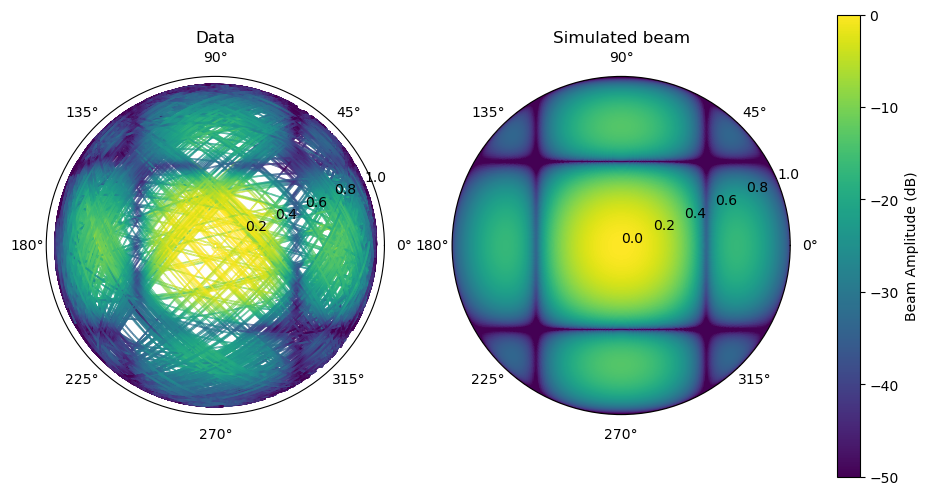

In [38]:
all_alt, all_az, all_power = get_pass_subset(len(passes))
#plot_pass_subset(all_alt, all_az, all_power)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, ncols=2, figsize=(12, 6))
Az, Za = np.meshgrid(beam.axis1_array, beam.axis2_array)
ax[0].scatter(np.deg2rad(all_az), np.sin(np.deg2rad(90 - all_alt)), c=all_power, s=0.1, vmin=-50, vmax=0)
im = ax[1].pcolormesh(Az, np.sin(Za), 10 * np.log10(beam.data_array[0,0,0].real), vmin=-50, vmax=0)
fig.colorbar(im, ax=ax.ravel().tolist(), label="Beam Amplitude (dB)")
for ax_ob in ax:
    ax_ob.grid(False)
ax[0].set_title("Data")
ax[1].set_title("Simulated beam")

Ratio of data to simulation (dB)

In [62]:
all_az_rad, all_za_rad, res = get_res(all_az, all_alt, all_power)

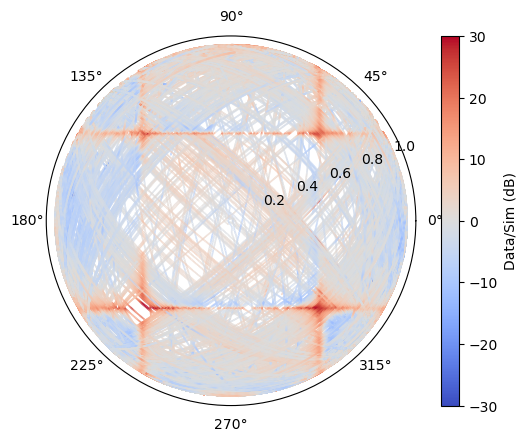

In [64]:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})

plt.scatter(all_az_rad, np.sin(all_za_rad), c=res, s=0.1, vmin=-30, vmax=30, cmap="coolwarm")
plt.colorbar(label="Data/Sim (dB)")
plt.grid(False)

Bin to 2 degree res. for visualization

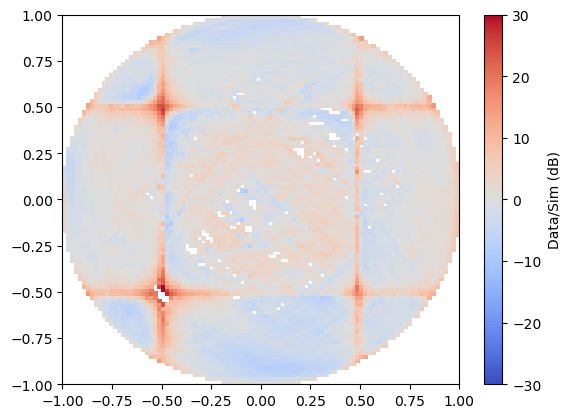

In [65]:
X = np.sin(all_za_rad) * np.cos(all_az_rad)
Y = np.sin(all_za_rad) * np.sin(all_az_rad)

mean_res, xedges, yedges, _ = binned_statistic_2d(X, Y, res, bins=np.linspace(-1, 1, num=101))
xcent = get_bin_cent(xedges)
ycent = get_bin_cent(yedges)

plt.pcolor(xcent, ycent, mean_res, vmin=-30, vmax=30, cmap="coolwarm")
plt.colorbar(label="Data/Sim (dB)")

Demonstrate (super)exponential tails with histogram

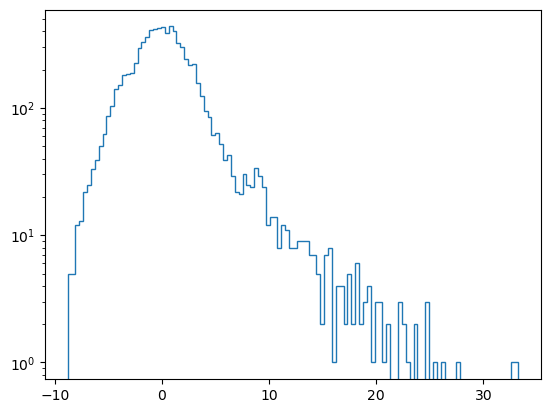

In [66]:
plt.hist(mean_res.real.flatten(), bins="auto", histtype="step", log=True);

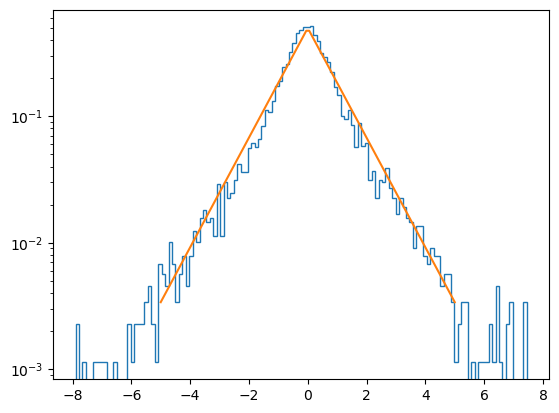

In [67]:
from scipy.stats import laplace

plt.hist(np.gradient(mean_res)[0].real.flatten(), bins="auto", histtype="step", log=True, density=True)
xplot = np.linspace(-5, 5, num=100)
plt.plot(xplot, laplace.pdf(xplot));

Ratio with only half the passes

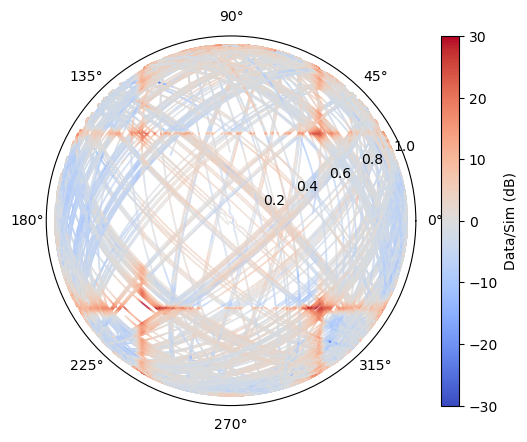

In [84]:
alt_deg, az_deg, power_db = get_pass_subset(1000)
az_rad, za_rad, res = get_res(az_deg, alt_deg, power_db)

X = np.sin(za_rad) * np.cos(az_rad)
Y = np.sin(za_rad) * np.sin(az_rad)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})

plt.scatter(az_rad, np.sin(za_rad), c=res.real, s=0.1, vmin=-30, vmax=30, cmap="coolwarm")
plt.colorbar(label="Data/Sim (dB)")
plt.grid(False)

At 2 degree binning

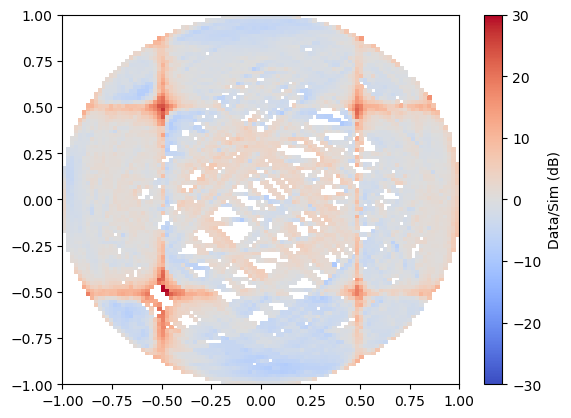

In [85]:
mean_res, xedges, yedges, _ = binned_statistic_2d(X, Y, res, bins=np.linspace(-1, 1, num=101))
xcent = get_bin_cent(xedges)
ycent = get_bin_cent(yedges)

plt.pcolor(xcent, ycent, mean_res.real, vmin=-30, vmax=30, cmap="coolwarm")
plt.colorbar(label="Data/Sim (dB)")

Do some Bayesian inference, first with SVI, then with MCMC (NUTS) on some short chains

In [86]:
theta_param = beam.axis2_array[1::10] # avoid the origin by a quarter degree
phi_param = beam.axis1_array[::10]

# ONCE, outside the model:
t_theta, t_phi, p, q, n_th, n_ph = make_knots_from_grid(theta_param, phi_param)
Nparam = n_th * n_ph

def model(za_data, az_data, Ndat, data=None, scale_vals=5, scale_grad=1, scale_noise=2):
    
    with numpyro.plate("Nparam", Nparam):
        surf_vals = numpyro.sample("surf_vals",
                                   dist.SoftLaplace(loc=0, scale=scale_vals))
    spl = SphericalSpline(t_theta, t_phi, surf_vals.reshape(n_th, n_ph), p, q)
    model_vals = eval_spline_batch(spl, za_data, az_data)
    grad = jnp.gradient(surf_vals.reshape(n_th, n_ph))
    pot1 = dist.SoftLaplace(loc=0, scale=scale_grad).log_prob(grad[0]).sum()
    pot2 = dist.SoftLaplace(loc=0, scale=scale_grad).log_prob(grad[1]).sum()
    numpyro.factor("grad_pot", pot1 + pot2)
    
    
    with numpyro.plate("Ndat", Ndat):
        obs = numpyro.sample("obs",
                             dist.SoftLaplace(loc=model_vals, scale=scale_noise),
                             obs=data)

In [87]:
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal, AutoDelta, AutoMultivariateNormal, AutoLaplaceApproximation

MAP = False
multivariate = False
if MAP:
    guide = AutoDelta(model)
elif multivariate:
    #guide = AutoMultivariateNormal(model)
    guide = AutoLaplaceApproximation(model)
else:
    guide = AutoDiagonalNormal(model)
key = random.key(8778)

svi = SVI(model, guide, numpyro.optim.Adam(1e-1), loss=Trace_ELBO())
svi_result = svi.run(key, 500, za_rad, az_rad, len(res), data=res.real)

100%|██████████| 500/500 [00:11<00:00, 43.40it/s, init loss: 1520132.6250, avg. loss [476-500]: 1151818.3750]


In [88]:
params = svi_result.params

Text(0.5, 0, 'Iteration')

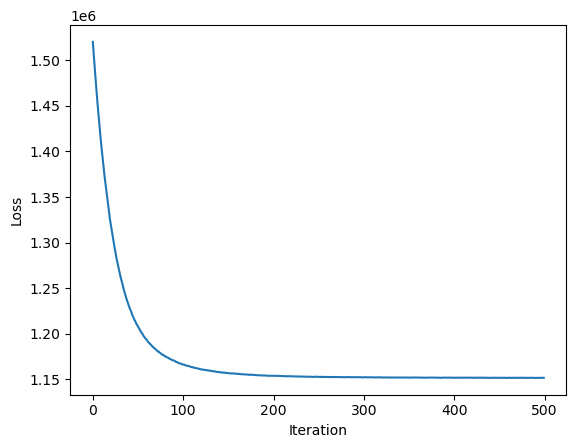

In [89]:
plt.plot(svi_result.losses)
plt.ylabel("Loss")
plt.xlabel("Iteration")

The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.


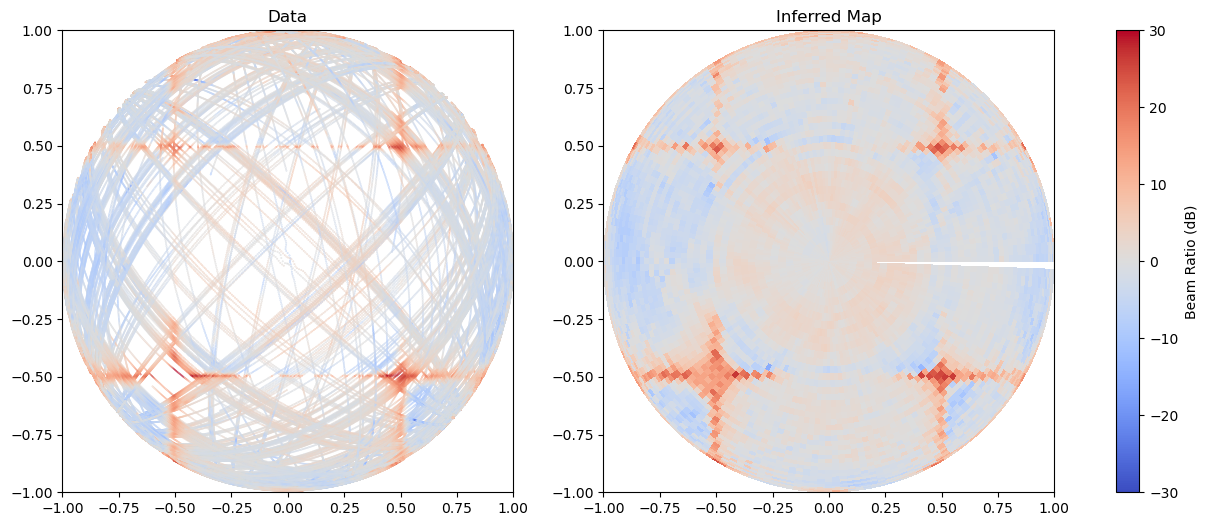

In [90]:
t_r = np.sin(t_theta[2:-2])
t_x = np.outer(t_r, np.cos(t_phi[2:-2]))
t_y = np.outer(t_r, np.sin(t_phi[2:-2]))

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))
ax[0].scatter(np.sin(za_rad) * np.cos(az_rad), np.sin(za_rad) * np.sin(az_rad), 
              c=res, s=0.1, vmin=-30, vmax=30, cmap="coolwarm")
im = ax[1].pcolor(t_x, t_y, params["auto_loc"].reshape(n_th, n_ph), vmin=-30, vmax=30, cmap="coolwarm")
for ax_ob in ax:
    ax_ob.set_xlim([-1, 1])
    ax_ob.set_ylim([-1, 1])
ax[0].set_title("Data")
ax[1].set_title("Inferred Map")
fig.colorbar(im, ax=ax.ravel().tolist(), label="Beam Ratio (dB)")

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.


Text(0.5, 1.0, 'Posterior Std.')

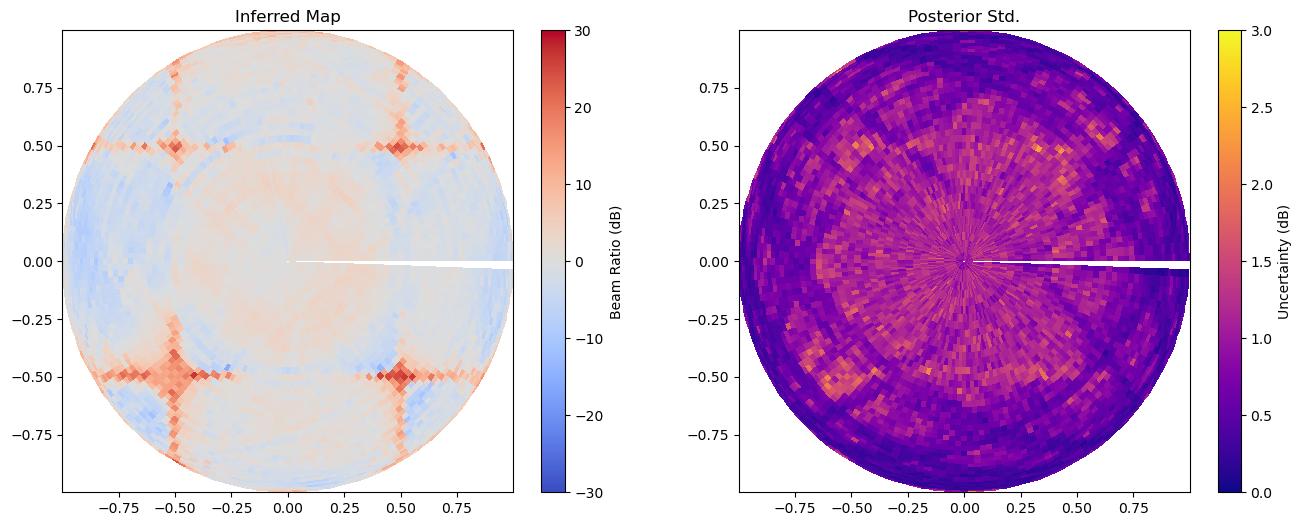

In [91]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6))
im1 = ax[0].pcolormesh(t_x, t_y, params["auto_loc"].reshape(n_th, n_ph), vmin=-30, vmax=30, cmap="coolwarm",
                       shading="nearest")
im2 = ax[1].pcolormesh(t_x, t_y, params["auto_scale"].reshape(n_th, n_ph), vmin=0, vmax=3, cmap="plasma",
                       shading="nearest")
fig.colorbar(im1, ax=ax[0], label="Beam Ratio (dB)")
fig.colorbar(im2, ax=ax[1], label="Uncertainty (dB)")
ax[0].set_title("Inferred Map")
ax[1].set_title("Posterior Std.")

The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.


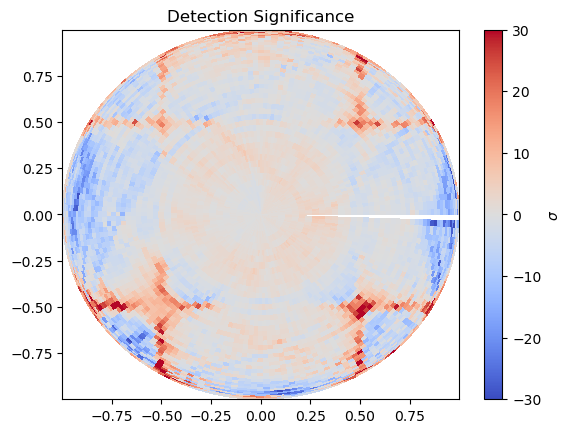

In [92]:
fig, ax = plt.subplots()
im = ax.pcolor(t_x, t_y, (params["auto_loc"] / params["auto_scale"]).reshape(n_th, n_ph), 
               vmin=-30, vmax=30, cmap="coolwarm")
ax.set_title("Detection Significance")
fig.colorbar(im, ax=ax, label=r"$\sigma$")

The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.


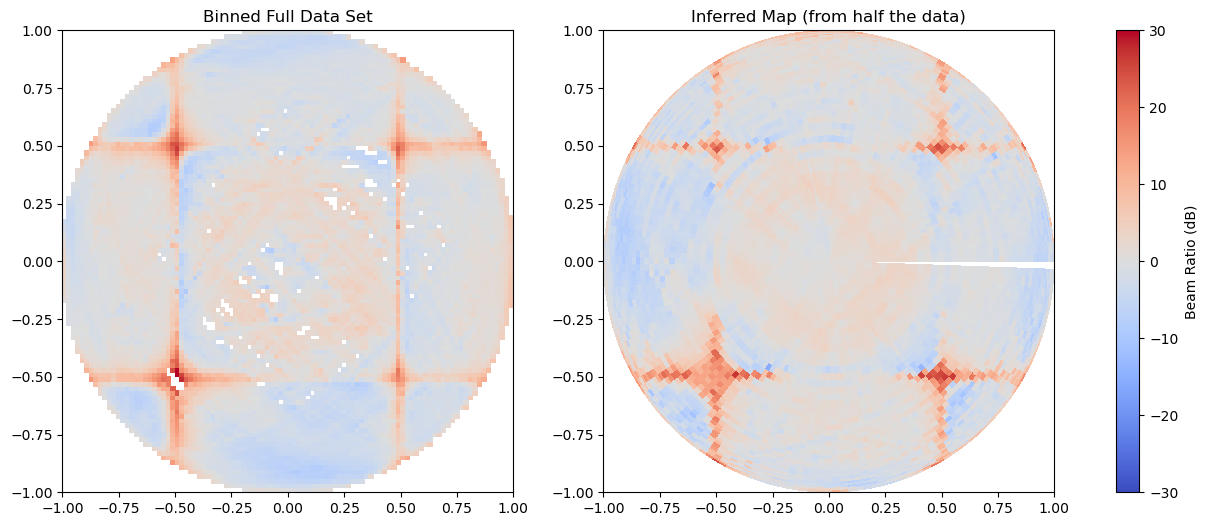

In [93]:
Xall = np.sin(all_za_rad) * np.cos(all_az_rad)
Yall = np.sin(all_za_rad) * np.sin(all_az_rad)
all_az_rad, all_za_rad, all_res = get_res(all_az, all_alt, all_power)

mean_res, xedges, yedges, _ = binned_statistic_2d(Xall, Yall, all_res, bins=np.linspace(-1, 1, num=101))
xcent = get_bin_cent(xedges)
ycent = get_bin_cent(yedges)



fig, ax = plt.subplots(ncols=2, figsize=(16, 6))
ax[0].pcolor(xcent, ycent, mean_res, vmin=-30, vmax=30, cmap="coolwarm")
im = ax[1].pcolor(t_x, t_y, params["auto_loc"].reshape(n_th, n_ph), vmin=-30, vmax=30, cmap="coolwarm")
for ax_ob in ax:
    ax_ob.set_xlim([-1, 1])
    ax_ob.set_ylim([-1, 1])
ax[0].set_title("Binned Full Data Set")
ax[1].set_title("Inferred Map (from half the data)")
fig.colorbar(im, ax=ax.ravel().tolist(), label="Beam Ratio (dB)")

Start from posterior mean from SVI run

In [ ]:

key = random.key(2735641724)
num_samples = 200
num_chains = 4
kernel = NUTS(model, init_strategy=init_to_value(values={"surf_vals": params["auto_loc"]}))
mcmc = MCMC(kernel, num_warmup=100, num_samples=num_samples, num_chains=num_chains)


In [ ]:
do_mcmc = True
if do_mcmc:
    mcmc.run(key, za_rad, az_rad, len(res.real), data=res.real)

Compiling.. :   0%|          | 0/300 [00:00<?, ?it/s]







Running chain 0:   0%|          | 0/300 [00:01<?, ?it/s]



Running chain 0:   5%|▌         | 15/300 [00:33<10:07,  2.13s/it]




Running chain 0:  15%|█▌        | 45/300 [01:14<06:20,  1.49s/it]




Running chain 0:  20%|██        | 60/300 [01:34<05:45,  1.44s/it]


Running chain 0:  30%|███       | 90/300 [02:07<04:21,  1.25s/it]


Running chain 0:  35%|███▌      | 105/300 [02:18<03:26,  1.06s/it]


Running chain 0:  40%|████      | 120/300 [02:27<02:44,  1.10it/s]


Running chain 0:  45%|████▌     | 135/300 [02:36<02:14,  1.23it/s]


Running chain 0:  50%|█████     | 150/300 [02:44<01:51,  1.34it/s]


Running chain 0:  55%|█████▌    | 165/300 [02:53<01:34,  1.43it/s]


Running chain 0:  60%|██████    | 180/300 [03:02<01:20,  1.50it/s]


Running chain 0:  65%|██████▌   | 195/300 [03:11<01:07,  1.55it/s]


Running chain 0:  70%|███████   | 210/300 [03:20<00:56,  1.58it/s]


Running chain 0:  75%|███████▌  | 225/300 [03:29<00:46,  1.60it/s]


Running chain 0:  80%|████████  | 240/300 [

In [ ]:
if do_mcmc:
    mcmc.print_summary()

In [ ]:
if do_mcmc:
    samps = mcmc.get_samples(group_by_chain=True)
    with open("MCMC_samples.pkl", "rb") as samps_file:
        pickle.dump(samps, samps_file)
else:
    with open("MCMC_samples.pkl", "rb") as samps_file:
        samps = pickle.load(samps_file)

Look at Gelman-Rubin Statistics (want these to be very close to 1)

Text(0.5, 0, 'Split Gelman-Rubin Statistic')

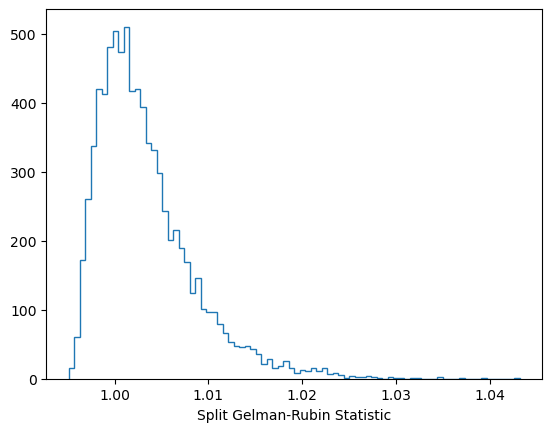

In [162]:
sgr = numpyro.diagnostics.split_gelman_rubin(samps["surf_vals"])
plt.hist(sgr, bins="auto", histtype="step");
plt.xlabel("Split Gelman-Rubin Statistic")

In [ ]:
corr = np.corrcoef(samps["surf_vals"].reshape(num_samples * num_chains, -1).T)

Look at posterior correlation matrix -- it seems very sparse, meaning SVI might be a decent approximation

16
0.6712753527006419


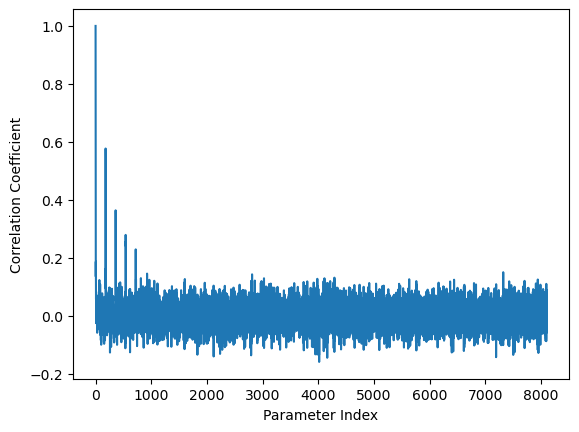

In [154]:
plt.plot(corr[:, 0])
plt.ylabel("Correlation Coefficient")
plt.xlabel("Parameter Index")
print(np.sum(corr[:, 0] > 0.2))
maxval = np.amax(corr[:, 0])
print(np.amax(corr[:, 0][corr[:, 0] < maxval]))

Compare SVI posterior to MCMC -- it does OK but tends to underestimate the error 
by a noticeable amount. Also has biases in places.

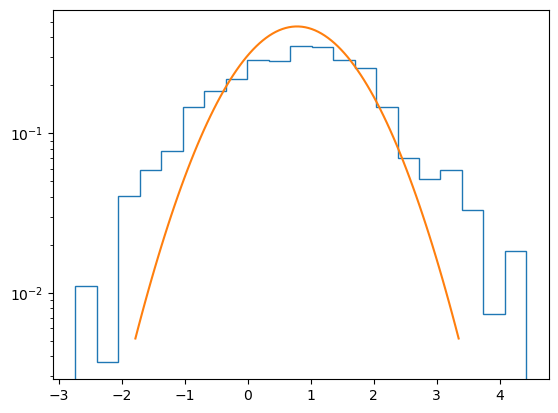

In [159]:
inspection_ind = 0
inspection_chain = 0

plt.hist(samps["surf_vals"].reshape(num_samples * num_chains, -1)[:, inspection_ind], bins="auto", histtype="step", 
         log=True, density=True)
svi_loc = params["auto_loc"][inspection_ind]
svi_scale = params["auto_scale"][inspection_ind]
xplot = 3 * svi_scale * np.linspace(-1, 1, num=100) + svi_loc
norm_log_dens = dist.Normal(
    loc=svi_loc,
    scale=svi_scale
).log_prob(xplot)
plt.plot(xplot, np.exp(norm_log_dens))